# Senaryo 3–4: Filtreli veri incelemesi

Bu not defteri `Baltalimani_Data_2025.xlsx` ham çıktısını `data_prep.load_raw` ile yükler ve aşağıdaki iki senaryo için **filtrelenmiş satır kümelerini** üretir:

3. **Doktor gezenler / poliklinik hataları** — aynı hasta ve aynı giriş gününde birden fazla doktor veya birden fazla randevu başlangıcı.
4. **Işık hızında muayeneler** — kabul ile sonlandırma arası süre < 1 dakika (0 dahil).

Simülasyonda bu kayıtları nasıl ele alacağınız (tekilleştirme, service time dışı bırakma) ayrı bir tasarım kararıdır; burada yalnızca **kanıt tabanlı filtre** sunulur.

In [1]:
from pathlib import Path

import pandas as pd

from data_prep import consolidate_xray_duplicates, load_raw

DATA_PATH = Path("Baltalimani_Data_2025.xlsx")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

raw = load_raw(str(DATA_PATH))
print(f"Ham satır: {len(raw):,}")
raw.head(2)

Ham satır: 12,263


,HASTA_ADI_SOYADI,TC_KIMLIK_NO,CINSIYET,DOKTOR_ADI,DOGUM_YILI,GIRIS_TARIHI,RANDEVU_BASLAMA_SAATI,MUAYENE_KABUL_ZAMANI,CAGRILMA_ZAMANI,TETKIK_ISTEK_SAATI,CEKIM_ZAMANI,RONTGEN_ODA_NO,MUAYENE_SONLANDIRMA_ZAMANI
0,NUR******EM,345******46,Kadın,DENİZ KARGIN,1962,2025-03-17,2025-03-17 09:30:00,2025-03-17 09:33:55,NaT,2025-03-17 09:34:37,2025-03-17 09:44:50,50000031.0,2025-03-17 09:59:22
1,İLH******OY,337******76,Erkek,MUHAMMED MERT,1953,2025-03-17,2025-03-17 15:30:00,2025-03-17 09:48:49,2025-03-17 10:35:23,2025-03-17 09:52:10,2025-03-17 10:24:18,50000031.0,2025-03-17 10:37:15


## 3. Doktor gezenler / poliklinik hataları

**Filtre mantığı:** `TC_KIMLIK_NO` ve `GIRIS_TARIHI` aynı olan gruplarda, `DOKTOR_ADI` veya `RANDEVU_BASLAMA_SAATI` için **birden fazla farklı değer** varsa o hastanın o güne ait **tüm** satırlar bu senaryoya girer.

Tek satırlık gruplar otomatik olarak elenir; aynı doktor + aynı randevu saati ile tekrarlayan satırlar (ör. çok açılı röntgen) bu kurala takılmaz.

In [2]:
patient_day_keys = ["TC_KIMLIK_NO", "GIRIS_TARIHI"]

multi_day = (
    raw.groupby(patient_day_keys, dropna=False)
    .agg(
        farkli_doktor=("DOKTOR_ADI", lambda s: s.nunique(dropna=False)),
        farkli_randevu=("RANDEVU_BASLAMA_SAATI", lambda s: s.nunique(dropna=False)),
    )
    .reset_index()
)
multi_day = multi_day[
    (multi_day["farkli_doktor"] > 1) | (multi_day["farkli_randevu"] > 1)
]

scenario3 = raw.merge(multi_day[patient_day_keys], on=patient_day_keys, how="inner")
scenario3 = scenario3.sort_values(
    [*patient_day_keys, "DOKTOR_ADI", "RANDEVU_BASLAMA_SAATI"],
    na_position="last",
)

n_groups = len(multi_day)
print(f"Etkilenen hasta-gün grubu: {n_groups:,}")
print(f"Toplam satır (bu grupların tamamı): {len(scenario3):,}")

summary3 = (
    scenario3.groupby(patient_day_keys, dropna=False)
    .agg(
        satir_sayisi=("TC_KIMLIK_NO", "size"),
        farkli_doktor=("DOKTOR_ADI", lambda s: s.nunique(dropna=False)),
        farkli_randevu_saati=(
            "RANDEVU_BASLAMA_SAATI",
            lambda s: s.nunique(dropna=False),
        ),
        doktorlar=("DOKTOR_ADI", lambda s: " | ".join(map(str, pd.unique(s)))),
    )
    .reset_index()
    .sort_values("satir_sayisi", ascending=False)
)
summary3.head(15)

Etkilenen hasta-gün grubu: 1,290
Toplam satır (bu grupların tamamı): 11,532


,TC_KIMLIK_NO,GIRIS_TARIHI,satir_sayisi,farkli_doktor,farkli_randevu_saati,doktorlar
362,205******28,2025-03-19,129,1,63,RAMADAN ÖKE
177,143******66,2025-03-20,117,1,67,GÖKHAN PEHLİVANOĞLU
592,304******02,2025-03-17,96,1,71,ALİ ÖNER
655,332******56,2025-03-18,91,1,37,KADİR İLKER YILDIZ
540,280******84,2025-03-18,88,1,56,MUSTAFA SERPİ
615,313******00,2025-03-21,80,1,54,AHMET KESKİN
243,163******84,2025-03-19,78,1,44,AHMET KESKİN
1013,498******16,2025-03-19,78,1,22,FERDİ DIRVAR
267,168******68,2025-03-21,76,1,32,ALPER KÖKSAL
533,277******00,2025-03-20,75,1,57,ASIM BÜLENT PAŞA


In [3]:
scenario3_path = OUT_DIR / "scenario3_doktor_gezenler.csv"
summary3_path = OUT_DIR / "scenario3_doktor_gezenler_ozet.csv"
scenario3.to_csv(scenario3_path, index=False, encoding="utf-8-sig")
summary3.to_csv(summary3_path, index=False, encoding="utf-8-sig")
print("Kaydedildi:", scenario3_path.resolve())
print("Kaydedildi:", summary3_path.resolve())

Kaydedildi: C:\Users\talha.yilmaz\Desktop\Talha\Simulation\outputs\scenario3_doktor_gezenler.csv
Kaydedildi: C:\Users\talha.yilmaz\Desktop\Talha\Simulation\outputs\scenario3_doktor_gezenler_ozet.csv


### Tekilleştirme notu (simülasyon)

Ham veride aynı (hasta, gün, doktor) için çoklu satır X-ray açılarından gelebilir. `data_prep.consolidate_xray_duplicates` bunları tek ziyarete indirger; **farklı doktorlar** kalırsa yine de çoklu ziyaret varsayımı gerekir.

Aşağıdaki tablo, senaryo 3 satırlarını önce doktor bazında konsolide edince kaç **hasta-gün** kaldığını gösterir (çoklu doktor sayısı hâlâ > 1 mi diye bakmak için).

In [4]:
s3_consolidated = consolidate_xray_duplicates(scenario3)
g2 = s3_consolidated.groupby(patient_day_keys, dropna=False)
still_multi_doc = g2.filter(
    lambda h: h["DOKTOR_ADI"].nunique(dropna=False) > 1
    or h["RANDEVU_BASLAMA_SAATI"].nunique(dropna=False) > 1,
)
print(f"Senaryo 3 satırı (konsolide öncesi): {len(scenario3):,}")
print(f"Senaryo 3 satırı (doktor bazında konsolide): {len(s3_consolidated):,}")
print(
    "Konsolide sonrası hâlâ çoklu doktor/randevu içeren satır: "
    f"{len(still_multi_doc):,}"
)
still_multi_doc.sort_values(
    [*patient_day_keys, "DOKTOR_ADI"], na_position="last"
).head(20)

Senaryo 3 satırı (konsolide öncesi): 11,532
Senaryo 3 satırı (doktor bazında konsolide): 1,306
Konsolide sonrası hâlâ çoklu doktor/randevu içeren satır: 32


,TC_KIMLIK_NO,GIRIS_TARIHI,DOKTOR_ADI,HASTA_ADI_SOYADI,CINSIYET,DOGUM_YILI,RANDEVU_BASLAMA_SAATI,MUAYENE_KABUL_ZAMANI,CAGRILMA_ZAMANI,TETKIK_ISTEK_SAATI,CEKIM_ZAMANI,RONTGEN_ODA_NO,MUAYENE_SONLANDIRMA_ZAMANI
14,102******40,2025-03-18,MUSTAFA SERPİ,SEZ******DA,Erkek,1972,2025-03-18 08:27:00,2025-03-18 08:45:17,2025-03-18 08:44:58,2025-03-18 08:48:10,2025-03-18 09:00:07,50000031.0,2025-03-18 09:26:17
15,102******40,2025-03-18,YASİN GÜLER,EME******R,Kadın,2005,2025-03-18 08:40:00,2025-03-18 09:08:56,2025-03-18 11:07:58,2025-03-18 09:10:13,2025-03-18 09:16:05,50000032.0,2025-03-18 11:09:33
18,103******00,2025-03-17,ALPER KÖKSAL,ENİ******,Kadın,1962,2025-03-17 10:54:00,2025-03-17 10:57:02,2025-03-17 11:52:09,2025-03-17 10:57:17,2025-03-17 11:38:31,50000031.0,2025-03-17 11:53:46
19,103******00,2025-03-17,MURAT ÖNDER,HAN******TO,Kadın,2000,2025-03-17 11:27:00,2025-03-17 11:16:56,2025-03-17 11:16:36,NaT,NaT,NaN,2025-03-17 11:19:10
45,108******22,2025-03-19,AHMET FIRAT BERKAY,HÜS******EN,Erkek,1984,2025-03-19 11:15:00,2025-03-19 09:21:38,2025-03-19 10:27:48,2025-03-19 09:23:03,2025-03-19 09:43:10,50000031.0,2025-03-19 10:32:14
46,108******22,2025-03-19,ALPER KÖKSAL,SON******LD,Kadın,1977,2025-03-19 09:09:00,NaT,2025-03-19 10:02:02,NaT,NaT,NaN,NaT
66,113******22,2025-03-20,AHMET MUTLU VURAL,ÖZL******MA,Kadın,1978,2025-03-20 09:04:00,2025-03-20 09:48:32,2025-03-20 11:03:49,2025-03-20 09:49:37,2025-03-20 10:25:03,50000032.0,2025-03-20 11:05:50
67,113******22,2025-03-20,ALİ ÖNER,BAR******İR,Erkek,2005,2025-03-20 08:38:00,2025-03-20 08:39:40,2025-03-20 08:39:02,NaT,NaT,NaN,2025-03-20 08:41:02
103,122******52,2025-03-21,AVNİ İLHAN BAYHAN,HÜS******AH,Erkek,2018,2025-03-21 13:50:00,2025-03-21 13:59:59,2025-03-21 14:09:55,2025-03-21 14:22:30,2025-03-21 14:37:50,50000032.0,2025-03-21 15:21:31
104,122******52,2025-03-21,OSMAN EMRE AYCAN,HÜS******AH,Erkek,2018,2025-03-21 13:50:00,2025-03-21 13:59:59,2025-03-21 14:09:55,2025-03-21 14:22:30,2025-03-21 14:37:50,50000032.0,NaT


## 4. Işık hızında muayeneler (Flash)

**Filtre mantığı:** `MUAYENE_SONLANDIRMA_ZAMANI - MUAYENE_KABUL_ZAMANI` süresi **1 dakikadan kısa** olan kayıtlar (0 ve negatif süreler dahil — veri/senkron hatası ipucu olabilir).

Eksik kabul veya sonlandırma zamanı olan satırlar bu listede yer almaz.

In [5]:
ONE_MIN = pd.Timedelta(minutes=1)
time_ok = raw["MUAYENE_KABUL_ZAMANI"].notna() & raw["MUAYENE_SONLANDIRMA_ZAMANI"].notna()
exam = raw.loc[time_ok].copy()
exam["muayene_suresi"] = exam["MUAYENE_SONLANDIRMA_ZAMANI"] - exam["MUAYENE_KABUL_ZAMANI"]
exam["muayene_suresi_saniye"] = exam["muayene_suresi"].dt.total_seconds()

scenario4 = exam[exam["muayene_suresi"] < ONE_MIN].sort_values("muayene_suresi")

print(f"Zamanları tam olan muayene: {len(exam):,}")
print(f"Süre < 1 dk: {len(scenario4):,} ({100 * len(scenario4) / len(exam):.2f}%)")
print("Süre dağılımı (saniye) — senaryo 4:")
print(scenario4["muayene_suresi_saniye"].describe(percentiles=[0.05, 0.5, 0.95]))
print(
    "<= 0 sn:",
    int((scenario4["muayene_suresi_saniye"] <= 0).sum()),
)

scenario4.head(15)

Zamanları tam olan muayene: 11,168
Süre < 1 dk: 292 (2.61%)
Süre dağılımı (saniye) — senaryo 4:
count      292.000000
mean      -289.126712
std       2392.688917
min     -19584.000000
5%           2.000000
50%         32.000000
95%         53.000000
max         58.000000
Name: muayene_suresi_saniye, dtype: float64
<= 0 sn: 9


,HASTA_ADI_SOYADI,TC_KIMLIK_NO,CINSIYET,DOKTOR_ADI,DOGUM_YILI,GIRIS_TARIHI,RANDEVU_BASLAMA_SAATI,MUAYENE_KABUL_ZAMANI,CAGRILMA_ZAMANI,TETKIK_ISTEK_SAATI,CEKIM_ZAMANI,RONTGEN_ODA_NO,MUAYENE_SONLANDIRMA_ZAMANI,muayene_suresi,muayene_suresi_saniye
5037,BUL******S,509******00,Erkek,OSMAN EMRE AYCAN,2017,2025-03-19,2025-03-19 11:45:00,2025-03-19 14:15:21,NaT,2025-03-19 14:24:17,2025-03-19 14:45:08,50000031.0,2025-03-19 08:48:57,-1 days +18:33:36,-19584.0
5002,BUL******S,509******00,Erkek,OSMAN EMRE AYCAN,2017,2025-03-19,2025-03-19 10:45:00,2025-03-19 14:15:21,NaT,2025-03-19 14:24:17,2025-03-19 14:45:08,50000031.0,2025-03-19 08:48:57,-1 days +18:33:36,-19584.0
5033,BUL******S,509******00,Erkek,OSMAN EMRE AYCAN,2017,2025-03-19,2025-03-19 09:45:00,2025-03-19 14:15:21,NaT,2025-03-19 14:24:17,2025-03-19 14:45:08,50000031.0,2025-03-19 08:48:57,-1 days +18:33:36,-19584.0
5047,BUL******S,509******00,Erkek,OSMAN EMRE AYCAN,2017,2025-03-19,2025-03-19 11:30:00,2025-03-19 14:15:21,NaT,2025-03-19 14:24:17,2025-03-19 14:45:08,50000031.0,2025-03-19 08:48:57,-1 days +18:33:36,-19584.0
4705,SAM******YR,382******02,Erkek,OSMAN EMRE AYCAN,1981,2025-03-19,2025-03-19 14:00:00,2025-03-19 12:15:44,NaT,2025-03-19 12:17:00,2025-03-19 12:23:47,50000031.0,2025-03-19 08:48:09,-1 days +20:32:25,-12455.0
12127,ESR******L,242******34,Kadın,MUHAMMED MERT,1992,2025-03-21,2025-03-21 09:20:00,2025-03-21 14:49:13,NaT,NaT,NaT,NaN,2025-03-21 14:41:52,-1 days +23:52:39,-441.0
11440,ESR******L,242******34,Kadın,MUHAMMED MERT,1992,2025-03-21,2025-03-21 14:50:00,2025-03-21 14:49:13,NaT,NaT,NaT,NaN,2025-03-21 14:41:52,-1 days +23:52:39,-441.0
11431,ESR******L,242******34,Kadın,MUHAMMED MERT,1992,2025-03-21,2025-03-21 08:40:00,2025-03-21 14:49:13,NaT,NaT,NaT,NaN,2025-03-21 14:41:52,-1 days +23:52:39,-441.0
11934,ESR******L,242******34,Kadın,MUHAMMED MERT,1992,2025-03-21,2025-03-21 14:50:00,2025-03-21 14:49:13,NaT,NaT,NaT,NaN,2025-03-21 14:41:52,-1 days +23:52:39,-441.0
12109,ERS******İN,429******82,Erkek,MEHMET ÖZBEY BÜYÜKKUŞCU,1990,2025-03-21,2025-03-21 09:33:00,2025-03-21 15:41:52,2025-03-21 15:37:30,NaT,NaT,NaN,2025-03-21 15:41:54,0 days 00:00:02,2.0


In [6]:
scenario4_path = OUT_DIR / "scenario4_flash_muayene.csv"
scenario4.to_csv(scenario4_path, index=False, encoding="utf-8-sig")
print("Kaydedildi:", scenario4_path.resolve())

Kaydedildi: C:\Users\talha.yilmaz\Desktop\Talha\Simulation\outputs\scenario4_flash_muayene.csv


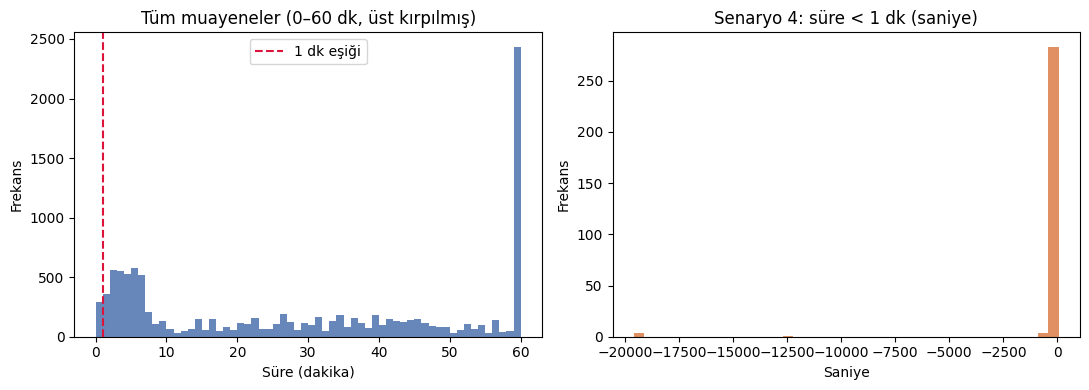

Grafik: C:\Users\talha.yilmaz\Desktop\Talha\Simulation\outputs\scenario4_muayene_sure_histogram.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(
    exam["muayene_suresi_saniye"].clip(lower=0, upper=3600) / 60.0,
    bins=60,
    color="#4C72B0",
    alpha=0.85,
)
axes[0].axvline(1.0, color="crimson", linestyle="--", label="1 dk eşiği")
axes[0].set_title("Tüm muayeneler (0–60 dk, üst kırpılmış)")
axes[0].set_xlabel("Süre (dakika)")
axes[0].set_ylabel("Frekans")
axes[0].legend()

sub = scenario4["muayene_suresi_saniye"]
axes[1].hist(sub, bins=40, color="#DD8452", alpha=0.9)
axes[1].set_title("Senaryo 4: süre < 1 dk (saniye)")
axes[1].set_xlabel("Saniye")
axes[1].set_ylabel("Frekans")

fig.tight_layout()
hist_path = OUT_DIR / "scenario4_muayene_sure_histogram.png"
fig.savefig(hist_path, dpi=150)
plt.show()
print("Grafik:", hist_path.resolve())